In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm

import cv2
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

In [1]:
from pathlib import Path

DATA_DIR = Path(r"E:\ediprj\data")

print("Data folder exists:", DATA_DIR.exists())

print("\nFolders inside data:")
for item in DATA_DIR.iterdir():
    print(item)

Data folder exists: True

Folders inside data:
E:\ediprj\data\datasetHand
E:\ediprj\data\processed
E:\ediprj\data\raw


In [2]:
from pathlib import Path

DATA_DIR = Path(r"E:\ediprj\data")

csv_files = list(DATA_DIR.rglob("training_labels.csv"))

print("Found CSV files:")

for f in csv_files:
    print(f)

Found CSV files:
E:\ediprj\data\datasetHand\Training\training_labels.csv


In [3]:
from pathlib import Path

DATA_DIR = Path(r"E:\ediprj\data")

train_csv = next(DATA_DIR.rglob("training_labels.csv"))

BASE_PATH = train_csv.parent.parent

print("BASE PATH:")
print(BASE_PATH)

print("\nTraining CSV:")
print(train_csv)

print("\nBASE PATH exists:", BASE_PATH.exists())
print("Training exists:", (BASE_PATH / "Training").exists())

BASE PATH:
E:\ediprj\data\datasetHand

Training CSV:
E:\ediprj\data\datasetHand\Training\training_labels.csv

BASE PATH exists: True
Training exists: True


In [4]:
TRAIN_PATH = BASE_PATH / "Training"
VAL_PATH = BASE_PATH / "Validation"
TEST_PATH = BASE_PATH / "Testing"

train_csv = TRAIN_PATH / "training_labels.csv"
val_csv = VAL_PATH / "validation_labels.csv"
test_csv = TEST_PATH / "testing_labels.csv"

train_images = TRAIN_PATH / "training_words"
val_images = VAL_PATH / "validation_words"
test_images = TEST_PATH / "testing_words"

print("TRAIN CSV:", train_csv)
print("TRAIN IMAGES:", train_images)

print("\nTrain CSV exists:", train_csv.exists())
print("Train images exists:", train_images.exists())

print("Val CSV exists:", val_csv.exists())
print("Val images exists:", val_images.exists())

print("Test CSV exists:", test_csv.exists())
print("Test images exists:", test_images.exists())

TRAIN CSV: E:\ediprj\data\datasetHand\Training\training_labels.csv
TRAIN IMAGES: E:\ediprj\data\datasetHand\Training\training_words

Train CSV exists: True
Train images exists: True
Val CSV exists: True
Val images exists: True
Test CSV exists: True
Test images exists: True


In [5]:
import pandas as pd
import numpy as np
import cv2
from pathlib import Path
from tqdm import tqdm

IMG_HEIGHT = 64
IMG_WIDTH = 256


def preprocess_image(image_path):
    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_GRAYSCALE
    )

    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    # Resize
    image = cv2.resize(
        image,
        (IMG_WIDTH, IMG_HEIGHT)
    )

    # Normalize 0-255 → 0-1
    image = image.astype(np.float32) / 255.0

    return image

In [6]:
def load_dataset(dataframe, image_folder):

    X = []
    y = []

    for _, row in tqdm(
        dataframe.iterrows(),
        total=len(dataframe)
    ):

        image_path = image_folder / row["IMAGE"]

        image = preprocess_image(image_path)

        # Add channel dimension
        image = np.expand_dims(image, axis=-1)

        X.append(image)
        y.append(row["label"])

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int32)

    return X, y

In [17]:
train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Testing samples:", len(test_df))

print("\nColumns:")
print(train_df.columns.tolist())

Training samples: 3120
Validation samples: 780
Testing samples: 780

Columns:
['IMAGE', 'MEDICINE_NAME', 'GENERIC_NAME']


In [20]:
classes = sorted(train_df["MEDICINE_NAME"].unique())

label_map = {
    medicine: i
    for i, medicine in enumerate(classes)
}

train_df["label"] = train_df["MEDICINE_NAME"].map(label_map)
val_df["label"] = val_df["MEDICINE_NAME"].map(label_map)
test_df["label"] = test_df["MEDICINE_NAME"].map(label_map)

print("Number of classes:", len(classes))
print("\nFirst 10 mappings:")

for i, medicine in enumerate(classes[:10]):
    print(i, "→", medicine)

Number of classes: 78

First 10 mappings:
0 → Ace
1 → Aceta
2 → Alatrol
3 → Amodis
4 → Atrizin
5 → Axodin
6 → Az
7 → Azithrocin
8 → Azyth
9 → Bacaid


In [21]:
X_train, y_train = load_dataset(
    train_df,
    train_images
)

X_val, y_val = load_dataset(
    val_df,
    val_images
)

X_test, y_test = load_dataset(
    test_df,
    test_images
)

100%|██████████| 780/780 [00:01<00:00, 753.14it/s]


In [22]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (3120, 64, 256, 1)
y_train: (3120,)
X_val: (780, 64, 256, 1)
y_val: (780,)
X_test: (780, 64, 256, 1)
y_test: (780,)


In [8]:
df = pd.read_csv(train_csv)

print("Number of samples:", len(df))
print(df.columns.tolist())

display(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'E:/ediprj/data/datasetHand/Training/training_labels.csv'

In [ ]:
medicine_names = sorted(
    df["MEDICINE_NAME"].unique()
)

num_classes = len(medicine_names)

print("Number of medicines:", num_classes)

Number of medicines: 78


In [ ]:
medicine_to_label = {
    medicine: i
    for i, medicine in enumerate(medicine_names)
}

label_to_medicine = {
    i: medicine
    for medicine, i in medicine_to_label.items()
}

In [ ]:
df["label"] = df["MEDICINE_NAME"].map(
    medicine_to_label
)

In [ ]:
df

,IMAGE,MEDICINE_NAME,GENERIC_NAME,label
0,0.png,Aceta,Paracetamol,1
1,1.png,Aceta,Paracetamol,1
2,2.png,Aceta,Paracetamol,1
3,3.png,Aceta,Paracetamol,1
4,4.png,Aceta,Paracetamol,1
...,...,...,...,...
3115,3115.png,Zithrin,Azithromycin Dihydrate,77
3116,3116.png,Zithrin,Azithromycin Dihydrate,77
3117,3117.png,Zithrin,Azithromycin Dihydrate,77
3118,3118.png,Zithrin,Azithromycin Dihydrate,77


In [ ]:
display(
    df[
        ["IMAGE", "MEDICINE_NAME", "GENERIC_NAME", "label"]
    ].head(10)
)

,IMAGE,MEDICINE_NAME,GENERIC_NAME,label
0,0.png,Aceta,Paracetamol,1
1,1.png,Aceta,Paracetamol,1
2,2.png,Aceta,Paracetamol,1
3,3.png,Aceta,Paracetamol,1
4,4.png,Aceta,Paracetamol,1
5,5.png,Aceta,Paracetamol,1
6,6.png,Aceta,Paracetamol,1
7,7.png,Aceta,Paracetamol,1
8,8.png,Aceta,Paracetamol,1
9,9.png,Aceta,Paracetamol,1


In [ ]:
print(
    df["MEDICINE_NAME"].value_counts().head(10)
)

MEDICINE_NAME
Aceta         40
Ace           40
Alatrol       40
Amodis        40
Atrizin       40
Axodin        40
Azithrocin    40
Azyth         40
Az            40
Bacaid        40
Name: count, dtype: int64


In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.333333,
    stratify=df["label"],
    random_state=42
)

In [ ]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

In [ ]:
train_df
train_df["label"].value_counts()

label
31    27
36    27
30    27
53    27
77    27
      ..
59    26
73    26
14    26
32    26
63    26
Name: count, Length: 78, dtype: int64

In [ ]:
train_df.count(col='label');

In [ ]:
print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))

Training: 2080
Validation: 520
Testing: 520


In [ ]:
IMG_HEIGHT = 64
IMG_WIDTH = 256

def preprocess_image(image_path):

    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_GRAYSCALE
    )

    if image is None:
        raise ValueError(
            f"Could not read image: {image_path}"
        )

    # Resize
    image = cv2.resize(
        image,
        (IMG_WIDTH, IMG_HEIGHT)
    )

    # Normalize
    image = image.astype(np.float32) / 255.0

    return image

In [ ]:
def load_dataset(dataframe, image_folder):

    X = []
    y = []

    for _, row in tqdm(
        dataframe.iterrows(),
        total=len(dataframe)
    ):

        image_path = image_folder / row["IMAGE"]

        image = preprocess_image(image_path)

        # Add channel
        image = np.expand_dims(
            image,
            axis=-1
        )

        X.append(image)
        y.append(row["label"])

    X = np.array(
        X,
        dtype=np.float32
    )

    y = np.array(
        y,
        dtype=np.int32
    )

    return X, y

In [ ]:
X_train, y_train = load_dataset(
    train_df,
    train_images
)

X_val, y_val = load_dataset(
    val_df,
    train_images
)

X_test, y_test = load_dataset(
    test_df,
    train_images
)

100%|██████████| 520/520 [00:01<00:00, 491.83it/s]


In [ ]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (2080, 64, 256, 1)
y_train: (2080,)
X_val: (520, 64, 256, 1)
y_val: (520,)
X_test: (520, 64, 256, 1)
y_test: (520,)


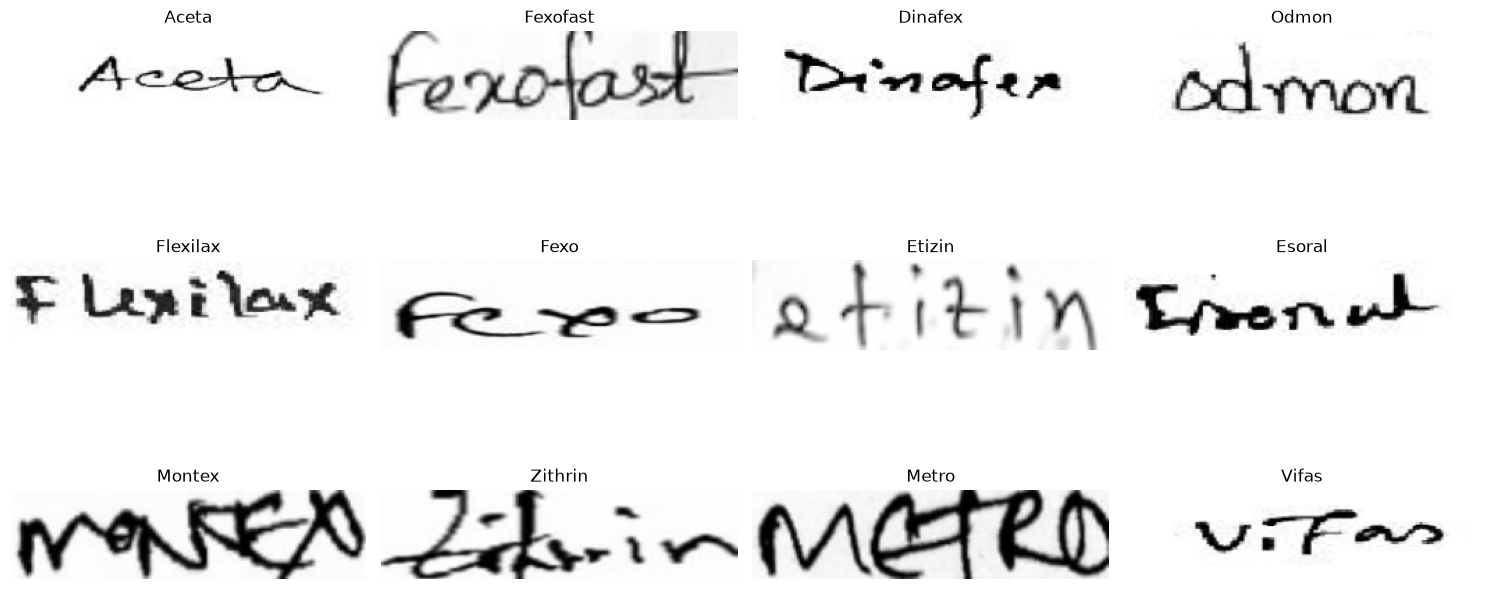

In [ ]:
plt.figure(figsize=(15, 8))

for i in range(12):

    plt.subplot(3, 4, i + 1)

    plt.imshow(
        X_train[i].squeeze(),
        cmap="gray"
    )

    plt.title(
        label_to_medicine[y_train[i]]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
tf.keras.backend.clear_session()

model = models.Sequential([

    layers.Input(
        shape=(64, 256, 1)
    ),

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        num_classes,
        activation="softmax"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 256, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 128, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 128, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 32, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 78)             │        10,062 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,297,166 (16.39 MB)

 Trainable params: 4,297,166 (16.39 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

In [ ]:
history = model.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=30,

    batch_size=32,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

Epoch 1/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 42s 577ms/step - accuracy: 0.0087 - loss: 4.4002 - val_accuracy: 0.0269 - val_loss: 4.3341
Epoch 2/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 35s 535ms/step - accuracy: 0.0308 - loss: 4.2450 - val_accuracy: 0.0615 - val_loss: 4.1493
Epoch 3/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 33s 502ms/step - accuracy: 0.1067 - loss: 3.8879 - val_accuracy: 0.1885 - val_loss: 3.7206
Epoch 4/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 32s 496ms/step - accuracy: 0.2159 - loss: 3.3376 - val_accuracy: 0.2519 - val_loss: 3.3766
Epoch 5/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 34s 525ms/step - accuracy: 0.3442 - loss: 2.7307 - val_accuracy: 0.3154 - val_loss: 2.9541
Epoch 6/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 31s 472ms/step - accuracy: 0.4486 - loss: 2.2058 - val_accuracy: 0.3712 - val_loss: 2.7666
Epoch 7/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 30s 460ms/step - accuracy: 0.5394 - loss: 1.7579 - val_accuracy: 0.4212 - val_loss: 2.7167
Epoch 8/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 33s 510ms/step - accuracy: 0.6308 - loss: 1.3645 - val_accu

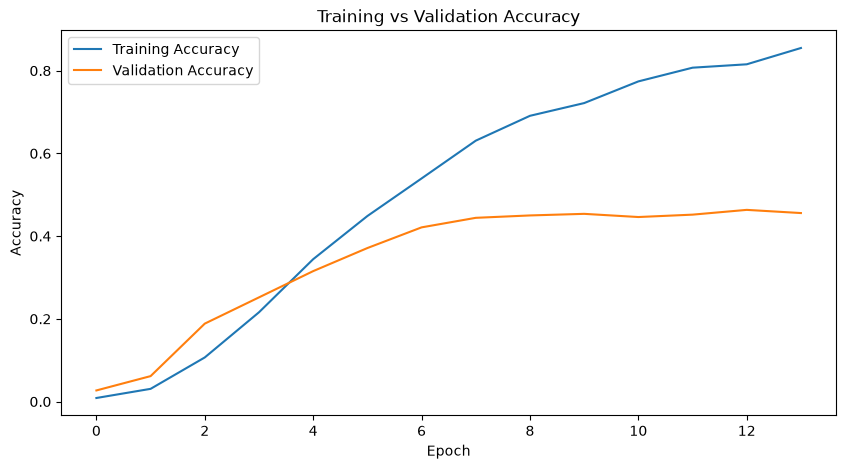

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

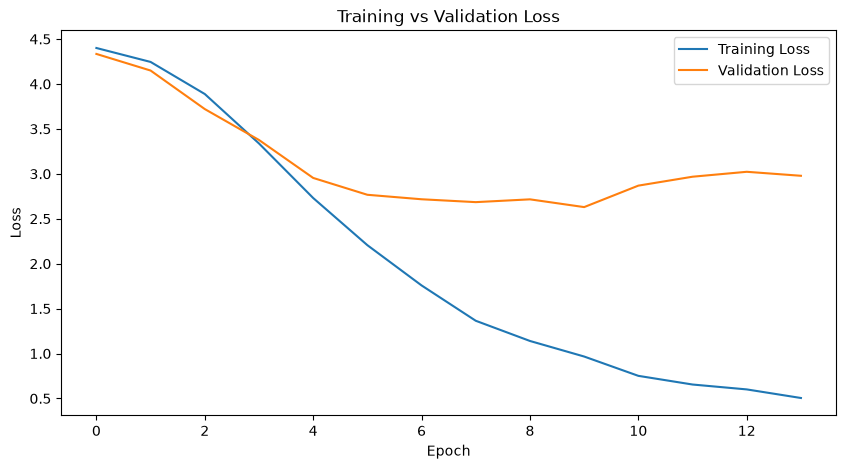

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - accuracy: 0.4827 - loss: 2.4964
Test Loss: 2.4963905811309814
Test Accuracy: 0.48269230127334595


In [ ]:
predictions = model.predict(
    X_test,
    verbose=1
)

pred_labels = np.argmax(
    predictions,
    axis=1
)

cm = confusion_matrix(
    y_test,
    pred_labels
)

print("Confusion matrix shape:", cm.shape)

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 148ms/step
Confusion matrix shape: (78, 78)


In [ ]:
class_names = [
    label_to_medicine[i]
    for i in range(num_classes)
]

report = classification_report(

    y_test,

    pred_labels,

    labels=np.arange(num_classes),

    target_names=class_names,

    zero_division=0
)

print(report)

              precision    recall  f1-score   support

         Ace       0.43      0.86      0.57         7
       Aceta       0.25      0.14      0.18         7
     Alatrol       0.50      0.14      0.22         7
      Amodis       0.50      0.43      0.46         7
     Atrizin       0.50      0.43      0.46         7
      Axodin       0.50      0.33      0.40         6
          Az       0.67      0.33      0.44         6
  Azithrocin       0.67      0.67      0.67         6
       Azyth       0.22      0.33      0.27         6
      Bacaid       0.38      0.43      0.40         7
    Backtone       0.50      0.50      0.50         6
    Baclofen       0.62      0.71      0.67         7
      Baclon       0.83      0.83      0.83         6
      Bacmax       0.71      0.71      0.71         7
       Beklo       0.60      0.43      0.50         7
     Bicozin       0.56      0.71      0.62         7
    Canazole       1.00      0.33      0.50         6
    Candinil       0.40    

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = (
    precision_recall_fscore_support(
        y_test,
        pred_labels,
        labels=np.arange(num_classes),
        zero_division=0
    )
)

results = pd.DataFrame({

    "Medicine": class_names,

    "Precision": precision,

    "Recall": recall,

    "F1": f1,

    "Support": support
})

display(
    results.sort_values(
        "F1"
    ).head(20)
)

,Medicine,Precision,Recall,F1,Support
63,Progut,0.125000,0.142857,0.133333,7
22,Diflu,0.125000,0.166667,0.142857,6
51,Montair,0.200000,0.142857,0.166667,7
1,Aceta,0.250000,0.142857,0.181818,7
18,Cetisoft,0.250000,0.142857,0.181818,7
50,Monas,0.250000,0.166667,0.200000,6
19,Conaz,0.250000,0.166667,0.200000,6
2,Alatrol,0.500000,0.142857,0.222222,7
33,Fixal,0.500000,0.142857,0.222222,7
69,Romycin,0.500000,0.142857,0.222222,7


In [ ]:
confusions = []

for actual in range(num_classes):

    for predicted in range(num_classes):

        if actual != predicted:

            count = cm[
                actual,
                predicted
            ]

            if count > 0:

                confusions.append({

                    "Actual":
                    label_to_medicine[actual],

                    "Predicted":
                    label_to_medicine[predicted],

                    "Count":
                    count
                })

confusions = sorted(
    confusions,
    key=lambda x: x["Count"],
    reverse=True
)

print("Top 20 Confusions:")

for item in confusions[:20]:

    print(
        f"{item['Actual']:20s} → "
        f"{item['Predicted']:20s} : "
        f"{item['Count']}"
    )

Top 20 Confusions:
Aceta                → Flexilax             : 2
Alatrol              → Ace                  : 2
Az                   → Ace                  : 2
Bacaid               → Provair              : 2
Beklo                → Diflu                : 2
Candinil             → Fexofast             : 2
Cetisoft             → Rhinil               : 2
Diflu                → Azyth                : 2
Diflu                → Metro                : 2
Dinafex              → Montair              : 2
Esoral               → M-Kast               : 2
Ketotab              → Opton                : 2
Montair              → Metro                : 2
Montex               → Flexilax             : 2
Napa                 → Flugal               : 2
Nizoder              → Flexilax             : 2
Odmon                → Fexo                 : 2
Progut               → Flamyd               : 2
Renova               → Exium                : 2
Sergel               → Fexofast             : 2
